# Neural Operators, ODEs, PDEs, and SILVA

This notebook derives a continuous ODE, its discrete repeated transition, a
steady-state fixed point, a spatial PDE residual, and a Fourier neural operator.
It then places the Fourier field inside a SILVA equilibrium point and trains a
small source-to-solution map for the Poisson equation.

The central connection is

$$
z^\star
=
\mathcal N\!\left[
\Psi\!\left(
S_\phi(a)
+H_\theta(z^\star)
+L_\theta(z^\star)
+G_\theta(z^\star)
+B_{\mathrm{operator},\theta}(z^\star)
\right)
\right].
$$

The task error, fixed-point residual, and PDE residual are kept separate because
they measure prediction, numerical equilibrium, and physical consistency.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [7](https://jseluis.github.io/silva-networks/paper/references/#ref-7), [31](https://jseluis.github.io/silva-networks/paper/references/#ref-31), [32](https://jseluis.github.io/silva-networks/paper/references/#ref-32). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch import nn

from silva_networks import (
    SILVABurgersRHS1D,
    SILVACortexLayer,
    SILVADirichletBoundary2D,
    SILVAEulerFlowBlock,
    SILVAFourierNeuralOperator,
    SILVAImplicitTimeStep,
    SILVAReactionDiffusionRHS2D,
    SolverConfig,
    boundary_error_2d,
    enforce_dirichlet_boundary_2d,
    poisson_residual_2d,
    relative_residual_norm,
    silva_point_architecture,
)

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(152)

## 1. From a State Map to a Function Map

A vector layer acts on a finite-dimensional state,

$$
f_\theta:\mathbb R^D\rightarrow\mathbb R^D,
$$

while a neural operator acts on functions,

$$
\mathcal G_\theta:\mathcal A(\Omega)\rightarrow\mathcal U(\Omega).
$$

A grid represents each function as a tensor. For a two-dimensional field with
$C$ channels, SILVA uses `(batch, channels, height, width)`. The architecture
inside the point must return that exact shape even if it temporarily enters
frequency space or changes spatial resolution.

## 2. ODE Flow, Euler Steps, and a Steady State

For the relaxation ODE

$$
\frac{dh}{dt}=-\lambda(h-u),
$$

the exact trajectory is

$$
h(t)=u+(h_0-u)e^{-\lambda t},
$$

and explicit Euler gives

$$
h_{k+1}=h_k-\lambda\Delta t(h_k-u).
$$

The terminal state after finitely many steps approximates the steady state
$h^\star=u$. The package ODE block exposes that finite trajectory directly.

In [3]:
class RelaxationField(nn.Module):
    def __init__(self, target, rate=1.0):
        super().__init__()
        self.register_buffer("target", target)
        self.rate = float(rate)

    def forward(self, h):
        return -self.rate * (h - self.target)


target = torch.tensor([[1.0, -0.5, 0.25]])
h0 = torch.zeros_like(target)
steps = 12
step_size = 0.2
rate = 1.0

flow = SILVAEulerFlowBlock(
    dim=3,
    steps=steps,
    step_size=step_size,
    vector_field=RelaxationField(target, rate),
)
terminal, trajectory = flow(h0, return_trajectory=True)
times = torch.arange(steps + 1) * step_size
exact = target + (h0 - target) * torch.exp(-rate * times[:, None, None])

print("terminal:", terminal)
print("exact final:", exact[-1])
print("Euler error:", float(torch.linalg.vector_norm(terminal - exact[-1])))

terminal: tensor([[ 0.9313, -0.4656,  0.2328]])
exact final: tensor([[ 0.9093, -0.4546,  0.2273]])
Euler error: 0.02520233951508999


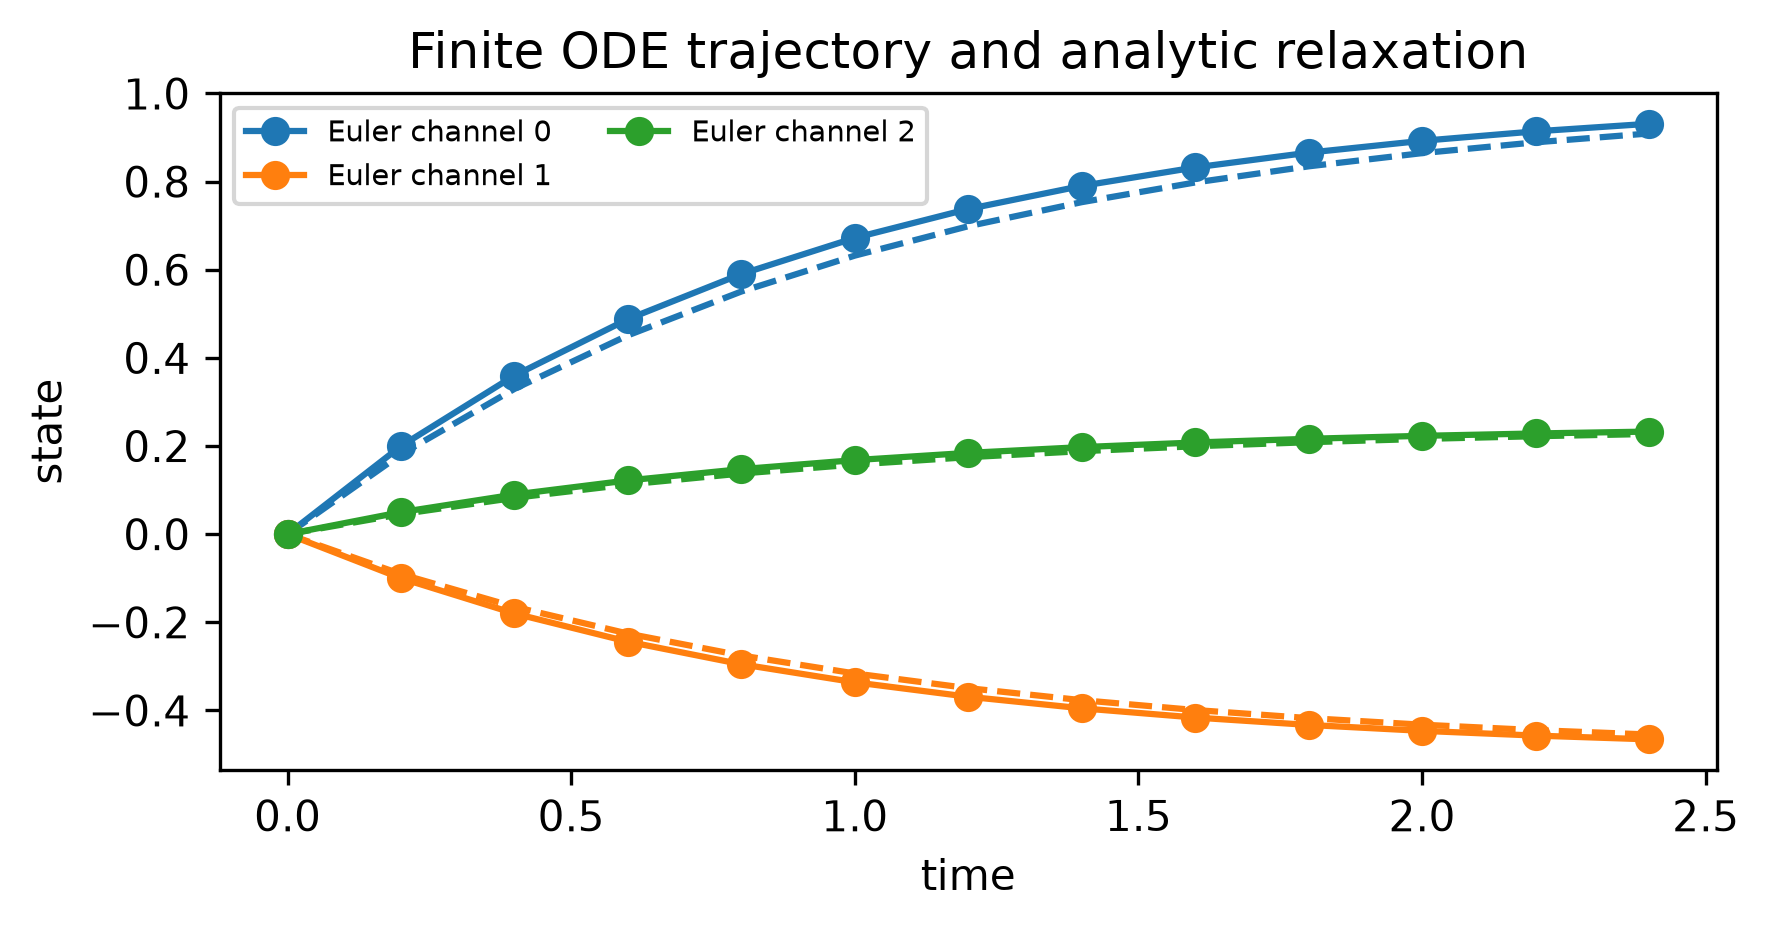

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.2))
for channel in range(target.shape[1]):
    ax.plot(times, trajectory[:, 0, channel], marker="o", label=f"Euler channel {channel}")
    ax.plot(times, exact[:, 0, channel], linestyle="--", color=ax.lines[-1].get_color())
ax.set_xlabel("time")
ax.set_ylabel("state")
ax.set_title("Finite ODE trajectory and analytic relaxation")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()

## 3. The Same Relaxation as a SILVA Fixed Point

Let $\beta=\lambda\Delta t$. The Euler map is

$$
T(h)=(1-\beta)h+\beta u.
$$

Its fixed point is $h^\star=u$. In the SILVA point below, `input_encoder`
produces the stimulus $\beta u$, while `state_network` produces the field
$(1-\beta)h$. Identity inner and outer activations keep this linear derivation
exact.

In [5]:
class Scale(nn.Module):
    def __init__(self, value):
        super().__init__()
        self.value = float(value)

    def forward(self, z):
        return self.value * z


beta = rate * step_size
steady_point = SILVACortexLayer(
    input_encoder=Scale(beta),
    state_network=Scale(1.0 - beta),
    activation=lambda z: z,
    output_activation=lambda z: z,
    normalize=False,
    config=SolverConfig(solver="picard", max_iter=80, tol=1e-7, alpha=1.0),
)
steady_result = steady_point(target, z0=h0, return_result=True)

print("equilibrium:", steady_result.z)
print("target:", target)
print("iterations:", steady_result.iterations)
print("final residual:", f"{steady_result.residual:.3e}")
assert torch.allclose(steady_result.z, target, atol=1e-4)

equilibrium: tensor([[ 1.0000, -0.5000,  0.2500]])
target: tensor([[ 1.0000, -0.5000,  0.2500]])
iterations: 67
final residual: 6.829e-08


The ODE block and equilibrium point answer different questions. The ODE block
returns the state at a chosen finite time. The SILVA point solves the
self-consistency equation and reports how closely the returned state satisfies
$T(h)-h=0$.

## 4. One Implicit PDE Step as One SILVA Point

For the diffusion equation

$$
\frac{\partial u}{\partial t}=D\Delta u,
$$

backward Euler evaluates the Laplacian at the unknown next state:

$$
u^{n+1}=u^n+\Delta t\,D\Delta_hu^{n+1}.
$$

This is already a SILVA fixed point. The previous field $u^n$ is the stimulus,
and the scaled finite-difference Laplacian is the local interaction. The next
cell compares the equilibrium result against a direct solve of

$$
\left(I-\Delta t\,D\Delta_h\right)u^{n+1}=u^n.
$$

In [6]:
class ZeroField(nn.Module):
    def forward(self, z):
        return torch.zeros_like(z)


class PeriodicDiffusionField(nn.Module):
    def __init__(self, coefficient):
        super().__init__()
        self.coefficient = float(coefficient)

    def forward(self, z):
        return self.coefficient * (torch.roll(z, 1, -1) - 2.0 * z + torch.roll(z, -1, -1))


grid_size = 24
diffusivity = 0.02
delta_t = 0.005
delta_x = 1.0 / grid_size
coefficient = delta_t * diffusivity / (delta_x * delta_x)
axis = torch.arange(grid_size) / grid_size
previous_field = (
    torch.sin(2.0 * math.pi * axis) + 0.35 * torch.sin(6.0 * math.pi * axis)
)[None, :]

implicit_diffusion = SILVACortexLayer(
    input_encoder=nn.Identity(),
    state_network=ZeroField(),
    local_terms=PeriodicDiffusionField(coefficient),
    activation=lambda z: z,
    output_activation=lambda z: z,
    normalize=False,
    initializer="zeros",
    config=SolverConfig(solver="picard", max_iter=80, tol=1e-8, alpha=1.0),
)
diffusion_result = implicit_diffusion(previous_field, return_result=True)

identity = torch.eye(grid_size)
laplacian = (
    torch.roll(identity, 1, 0) - 2.0 * identity + torch.roll(identity, -1, 0)
) / (delta_x * delta_x)
direct_next = torch.linalg.solve(
    identity - delta_t * diffusivity * laplacian,
    previous_field[0],
)
step_error = torch.linalg.vector_norm(diffusion_result.z[0] - direct_next)

print("diffusion coefficient:", f"{coefficient:.3f}")
print("iterations:", diffusion_result.iterations)
print("final fixed-point residual:", f"{diffusion_result.residual:.3e}")
print("error against direct implicit solve:", f"{float(step_error):.3e}")
assert torch.allclose(diffusion_result.z[0], direct_next, atol=1e-5)

diffusion coefficient: 0.058
iterations: 80
final fixed-point residual: 9.424e-08
error against direct implicit solve: 3.746e-07


For a reaction-diffusion equation with forcing,

$$
\frac{\partial u}{\partial t}=D\Delta u+r_\theta(u)+s,
$$

the same implicit step uses $u^n+\Delta t\,s$ as `input_encoder` output,
$\Delta t\,r_\theta(u)$ as `self_terms`, and
$\Delta t\,D\Delta_hu$ as `local_terms`. A spectral closure or conservation
correction can enter through `global_terms` without changing the fixed-point
solver.

## 5. A PDE with an Analytic Family of Solutions

On the unit square, consider

$$
-\Delta u(x,y)=q(x,y),
\qquad u|_{\partial\Omega}=0.
$$

For integers $m,n\geq1$,

$$
u_{mn}(x,y)=\sin(m\pi x)\sin(n\pi y)
$$

satisfies the boundary condition, and

$$
-\Delta u_{mn}
=\pi^2(m^2+n^2)u_{mn}.
$$

Random linear combinations of these modes provide paired source and solution
fields without calling an external PDE solver.

In [7]:
POISSON_SCALE = math.pi**2 * 18.0


def make_poisson_batch(samples=16, size=16, seed=153):
    generator = torch.Generator().manual_seed(seed)
    axis = torch.linspace(0.0, 1.0, size)
    y, x = torch.meshgrid(axis, axis, indexing="ij")
    solution = torch.zeros(samples, 1, size, size)
    physical_source = torch.zeros_like(solution)
    modes = ((1, 1), (1, 2), (2, 1), (2, 2), (3, 1))
    coefficients = 0.35 * torch.randn(samples, len(modes), generator=generator)

    for index, (m, n) in enumerate(modes):
        basis = torch.sin(m * math.pi * x) * torch.sin(n * math.pi * y)
        amplitude = coefficients[:, index, None, None, None]
        solution = solution + amplitude * basis
        physical_source = physical_source + amplitude * (math.pi**2 * (m * m + n * n)) * basis

    normalized_source = physical_source / POISSON_SCALE
    return normalized_source, solution, physical_source


source, solution, physical_source = make_poisson_batch()
print("source:", tuple(source.shape), "range", float(source.min()), float(source.max()))
print("solution:", tuple(solution.shape), "range", float(solution.min()), float(solution.max()))

source: (16, 1, 16, 16) range -0.4958105683326721 0.4397468864917755
solution: (16, 1, 16, 16) range -1.2100932598114014 1.0730386972427368


## 6. Discrete PDE Residual

For grid spacing $h$, the five-point Laplacian is

$$
(\Delta_hu)_{i,j}
=\frac{u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}-4u_{i,j}}{h^2}.
$$

The physical residual and its relative norm are

$$
r_{\mathrm{PDE}}=-\Delta_hu-q,
\qquad
\varepsilon_{\mathrm{PDE}}
=\frac{\|r_{\mathrm{PDE}}\|_2}{\|q\|_2}.
$$

In [8]:
def poisson_residual(field, source_field):
    spacing = 1.0 / (field.shape[-1] - 1)
    center = field[..., 1:-1, 1:-1]
    laplacian = (
        field[..., 2:, 1:-1]
        + field[..., :-2, 1:-1]
        + field[..., 1:-1, 2:]
        + field[..., 1:-1, :-2]
        - 4.0 * center
    ) / (spacing * spacing)
    return -laplacian - source_field[..., 1:-1, 1:-1]


target_pde_residual = poisson_residual(solution, physical_source)
target_relative_residual = torch.linalg.vector_norm(target_pde_residual) / torch.linalg.vector_norm(
    physical_source[..., 1:-1, 1:-1]
)
print("analytic field, discrete PDE residual:", f"{float(target_relative_residual):.3e}")

analytic field, discrete PDE residual: 2.221e-02


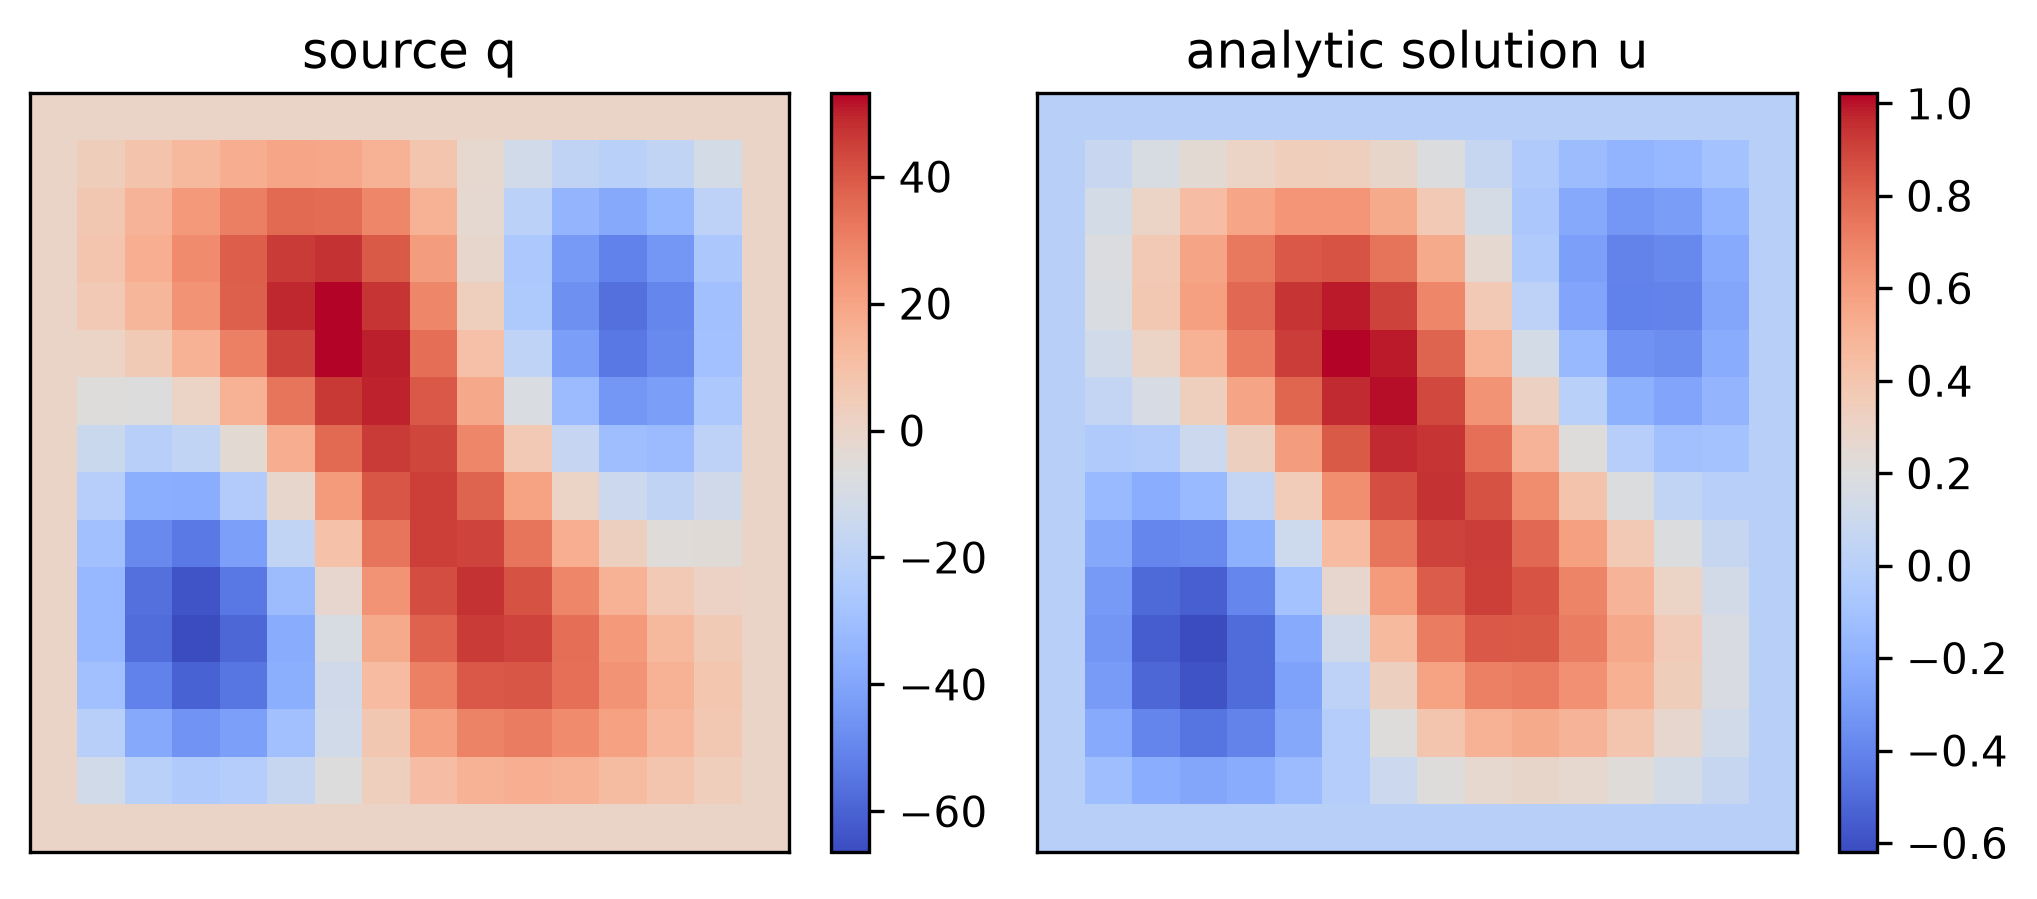

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
images = [physical_source[0, 0], solution[0, 0]]
titles = ["source q", "analytic solution u"]
for ax, image, title in zip(axes, images, titles):
    artist = ax.imshow(image.detach(), cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(artist, ax=ax, fraction=0.046)
fig.tight_layout()

## 7. Fourier Operator from the Implementation

For a state $z$ sampled on a grid, the package computes

$$
\widehat z=\mathcal F_hz,
\qquad
\widehat v_o(k)=\sum_iR_{oi}(k)\widehat z_i(k),
\qquad k\in\mathcal K,
$$

zeros unretained modes, and returns

$$
B_\theta(z)
=s\left(\mathcal F_h^{-1}\widehat v+Pz\right).
$$

The spectral term is global over the grid. The learned $1\times1$ projection
$P$ is local in space and mixes channels.

In [10]:
fourier_field = silva_point_architecture(
    "fourier_operator",
    channels=4,
    modes_height=3,
    modes_width=3,
    scale=0.05,
)
probe = torch.randn(2, 4, 12, 10)
spectral_branch = fourier_field.spectral(probe)
local_branch = fourier_field.local(probe)
combined = fourier_field(probe)

assert torch.allclose(
    combined,
    fourier_field.scale * (spectral_branch + local_branch),
)
print("top complex weights:", tuple(fourier_field.spectral.weight_top.shape))
print("bottom complex weights:", tuple(fourier_field.spectral.weight_bottom.shape))
print("spectral branch:", tuple(spectral_branch.shape))
print("local branch:", tuple(local_branch.shape))
print("combined field:", tuple(combined.shape))

top complex weights: (4, 4, 3, 3, 2)
bottom complex weights: (4, 4, 3, 3, 2)
spectral branch: (2, 4, 12, 10)
local branch: (2, 4, 12, 10)
combined field: (2, 4, 12, 10)


In [11]:
for height, width in ((12, 10), (18, 14), (24, 20)):
    grid = torch.randn(1, 4, height, width)
    field = fourier_field(grid)
    assert field.shape == grid.shape
    print(f"resolution {height:2d} x {width:2d} -> {tuple(field.shape)}")

resolution 12 x 10 -> (1, 4, 12, 10)
resolution 18 x 14 -> (1, 4, 18, 14)
resolution 24 x 20 -> (1, 4, 24, 20)


## 8. Put the Neural Operator Inside SILVA

The Poisson source is lifted into $C$ state channels:

$$
s=R_\phi(q).
$$

The point then solves

$$
z^\star
=\tanh\!\left[
s
+B_{\mathrm{FNO},\theta}(z^\star)
+L_\theta(z^\star)
\right].
$$

The readout projects the equilibrium state to one solution channel and a fixed
boundary mask enforces $\widehat u=0$ on the square boundary.

In [12]:
class ScaledDepthwiseLocal(nn.Module):
    def __init__(self, channels, scale=0.05):
        super().__init__()
        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            groups=channels,
        )
        self.scale = float(scale)

    def forward(self, z):
        return self.scale * self.conv(z)


class PoissonSILVA(nn.Module):
    def __init__(self, channels=4, modes=4):
        super().__init__()
        self.point = SILVACortexLayer(
            input_encoder=nn.Conv2d(1, channels, kernel_size=1),
            state_network=silva_point_architecture(
                "fourier_operator",
                channels=channels,
                modes_height=modes,
                modes_width=modes,
                scale=0.05,
            ),
            local_terms=ScaledDepthwiseLocal(channels, scale=0.05),
            output_network=nn.Conv2d(channels, channels, kernel_size=1),
            normalize=False,
            activation=torch.tanh,
            output_activation=torch.tanh,
            config=SolverConfig(solver="picard", max_iter=20, tol=1e-5, alpha=0.60),
        )
        self.readout = nn.Conv2d(channels, 1, kernel_size=1)

    @staticmethod
    def boundary_mask(field):
        height, width = field.shape[-2:]
        y = torch.linspace(0.0, 1.0, height, device=field.device, dtype=field.dtype)
        x = torch.linspace(0.0, 1.0, width, device=field.device, dtype=field.dtype)
        yy, xx = torch.meshgrid(y, x, indexing="ij")
        return 16.0 * xx * (1.0 - xx) * yy * (1.0 - yy)

    def forward(self, source_field, return_result=False):
        result = self.point(source_field, return_result=True)
        prediction = self.readout(result.z) * self.boundary_mask(result.z)
        return (prediction, result) if return_result else prediction

## 9. Train on a Tiny Analytic Operator Dataset

This is a compact executable example rather than an accuracy benchmark. Every
training sample is a function pair $(q,u)$, and the same model parameters are
used across all grid coordinates and source fields.

In [13]:
torch.manual_seed(154)
train_source, train_solution, _ = make_poisson_batch(samples=24, size=16, seed=154)
model = PoissonSILVA(channels=6, modes=4)
optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-2)
losses = []

for epoch in range(80):
    optimizer.zero_grad()
    prediction = model(train_source)
    loss = F.mse_loss(prediction, train_solution)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

print("initial loss:", f"{losses[0]:.4e}")
print("final loss:", f"{losses[-1]:.4e}")
assert losses[-1] < losses[0]

initial loss: 1.3650e-01
final loss: 1.9593e-02


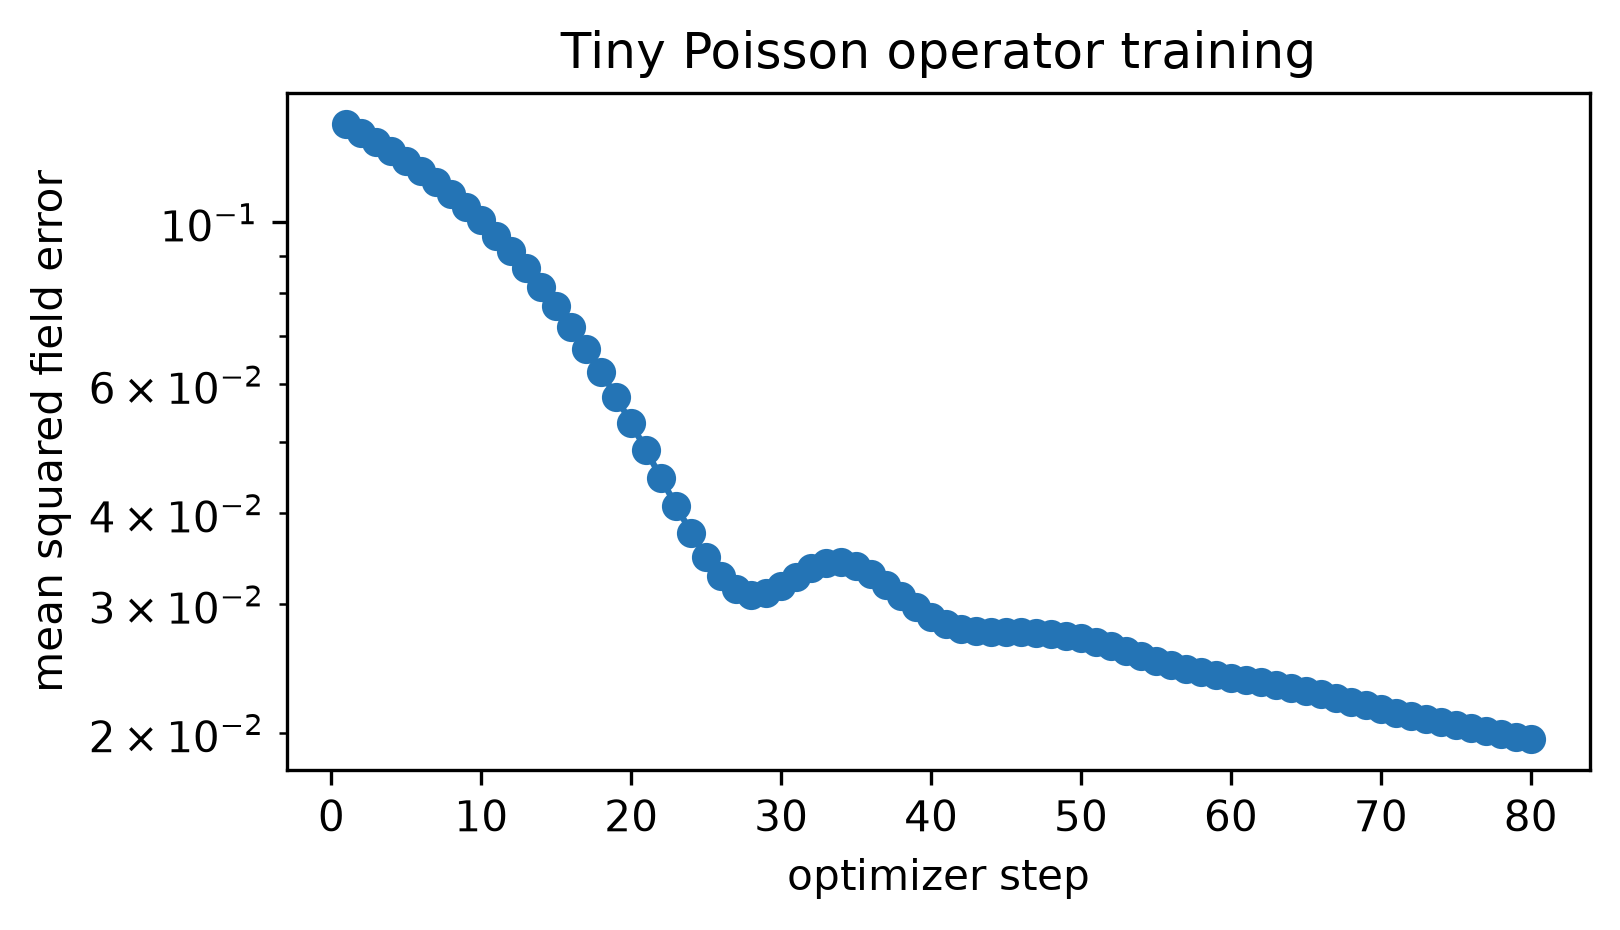

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(range(1, len(losses) + 1), losses, marker="o", color="#2474b5")
ax.set_xlabel("optimizer step")
ax.set_ylabel("mean squared field error")
ax.set_yscale("log")
ax.set_title("Tiny Poisson operator training")
fig.tight_layout()

## 10. Evaluate Prediction, Equilibrium, and PDE Residuals

The supervised relative error is

$$
\varepsilon_{\mathrm{field}}
=\frac{\|\widehat u-u\|_2}{\|u\|_2}.
$$

The final solver residual measures $\|F_\theta(z_K,q)-z_K\|_2$. The PDE residual
measures $\|-\Delta_h\widehat u-q\|_2$. A low value of one does not imply a low
value of either other quantity.

In [15]:
test_source, test_solution, test_physical_source = make_poisson_batch(
    samples=4,
    size=16,
    seed=155,
)
with torch.no_grad():
    test_prediction, test_result = model(test_source, return_result=True)

field_error = torch.linalg.vector_norm(test_prediction - test_solution) / torch.linalg.vector_norm(
    test_solution
)
prediction_pde_residual = poisson_residual(test_prediction, test_physical_source)
pde_error = torch.linalg.vector_norm(prediction_pde_residual) / torch.linalg.vector_norm(
    test_physical_source[..., 1:-1, 1:-1]
)
boundary_error = torch.cat(
    [
        test_prediction[..., 0, :].reshape(-1),
        test_prediction[..., -1, :].reshape(-1),
        test_prediction[..., :, 0].reshape(-1),
        test_prediction[..., :, -1].reshape(-1),
    ]
).abs().max()

print("relative field error:", f"{float(field_error):.3e}")
print("relative PDE residual:", f"{float(pde_error):.3e}")
print("maximum boundary error:", f"{float(boundary_error):.3e}")
print("fixed-point residuals:", [f"{value:.3e}" for value in test_result.residuals])
assert float(field_error) < 0.65
assert float(boundary_error) == 0.0
assert test_result.residuals[-1] < test_result.residuals[0]

relative field error: 3.514e-01
relative PDE residual: 8.425e-01
maximum boundary error: 0.000e+00
fixed-point residuals: ['2.150e+01', '1.019e+01', '5.152e+00', '2.807e+00', '1.646e+00', '1.025e+00', '6.659e-01', '4.445e-01', '3.021e-01', '2.078e-01', '1.442e-01', '1.008e-01', '7.078e-02', '4.993e-02', '3.534e-02', '2.509e-02', '1.786e-02', '1.273e-02', '9.095e-03', '6.507e-03']


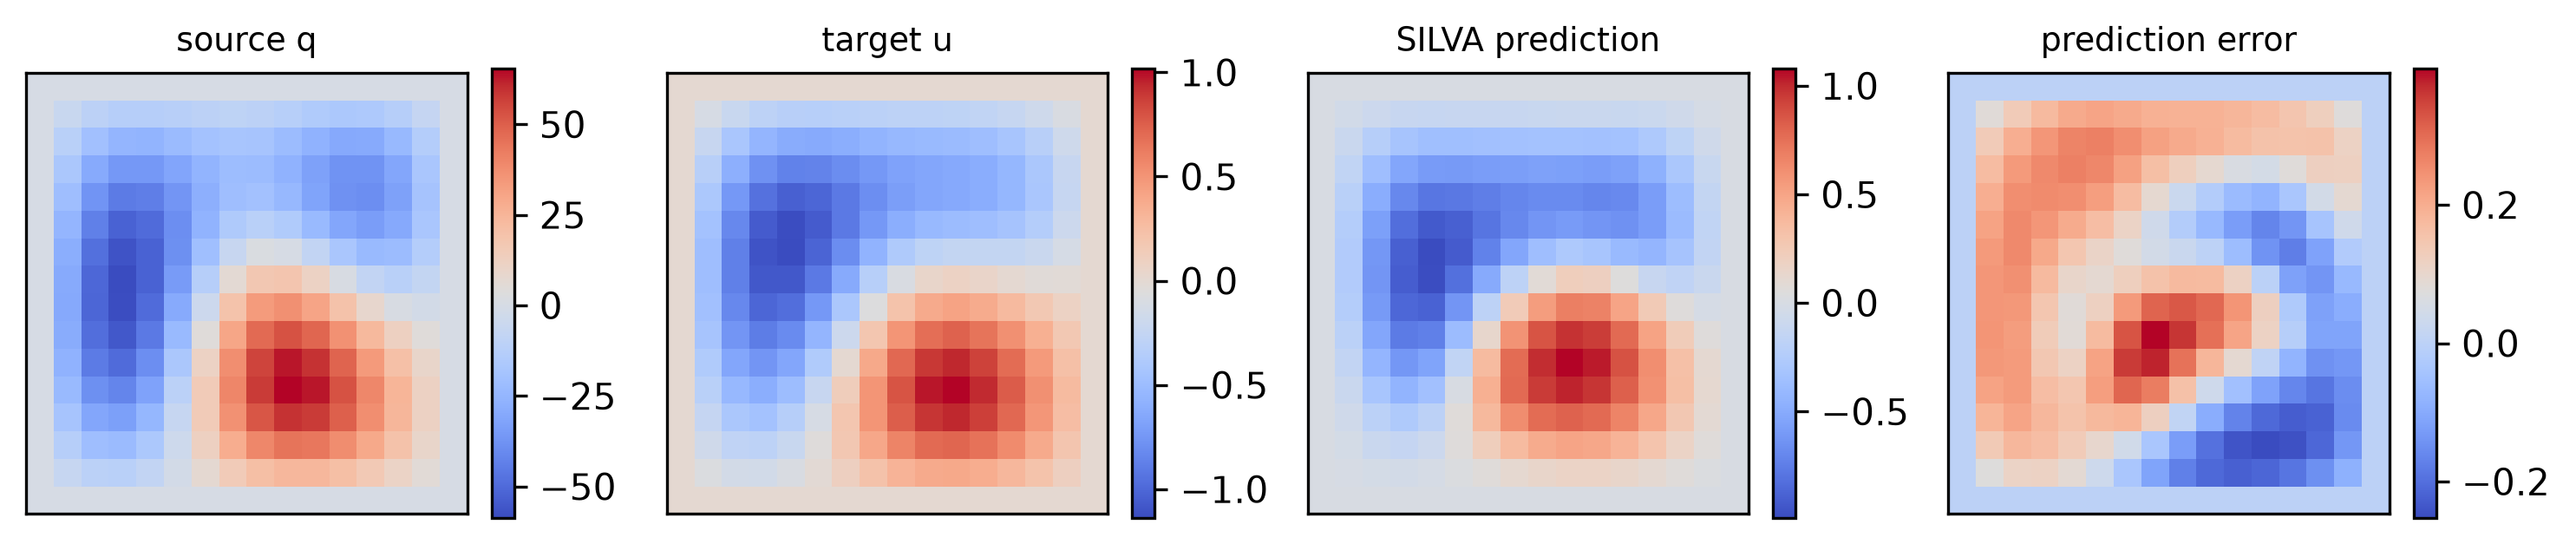

In [16]:
error = test_prediction[0, 0] - test_solution[0, 0]
panels = [
    test_physical_source[0, 0],
    test_solution[0, 0],
    test_prediction[0, 0],
    error,
]
titles = ["source q", "target u", "SILVA prediction", "prediction error"]

fig, axes = plt.subplots(1, 4, figsize=(10, 2.7))
for ax, image, title in zip(axes, panels, titles):
    artist = ax.imshow(image.detach(), cmap="coolwarm")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(artist, ax=ax, fraction=0.046)
fig.tight_layout()

## 11. Solver Damping and Architecture Scale

For the undamped transition $F$ and Picard damping $\alpha$,

$$
T_\alpha(z)=(1-\alpha)z+\alpha F(z),
\qquad
J_{T_\alpha}=(1-\alpha)I+\alpha J_F.
$$

The Fourier architecture scale multiplies only its spectral-plus-local field.
The next experiment holds the random initialization and source fixed while
changing both controls. The values are numerical compatibility diagnostics, not
an architecture ranking.

In [17]:
def residual_ratio_for(scale, alpha):
    torch.manual_seed(156)
    point = SILVACortexLayer(
        input_encoder=nn.Conv2d(1, 3, kernel_size=1),
        state_network=silva_point_architecture(
            "fourier_operator",
            channels=3,
            modes_height=3,
            modes_width=3,
            scale=scale,
        ),
        normalize=False,
        config=SolverConfig(solver="picard", max_iter=6, alpha=alpha),
    )
    result = point(test_source[:1], return_result=True)
    return result.residuals[-1] / result.residuals[0]


scales = (0.02, 0.05, 0.10)
alphas = (0.15, 0.35, 0.60)
sweep = {
    scale: [residual_ratio_for(scale, alpha) for alpha in alphas]
    for scale in scales
}
sweep

{0.02: [0.44528000148573765, 0.11730033930874181, 0.010576625460022795],
 0.05: [0.4478287441596757, 0.11953335863652652, 0.011262735066935379],
 0.1: [0.45253220963164537, 0.12397953177913386, 0.012746696687176129]}

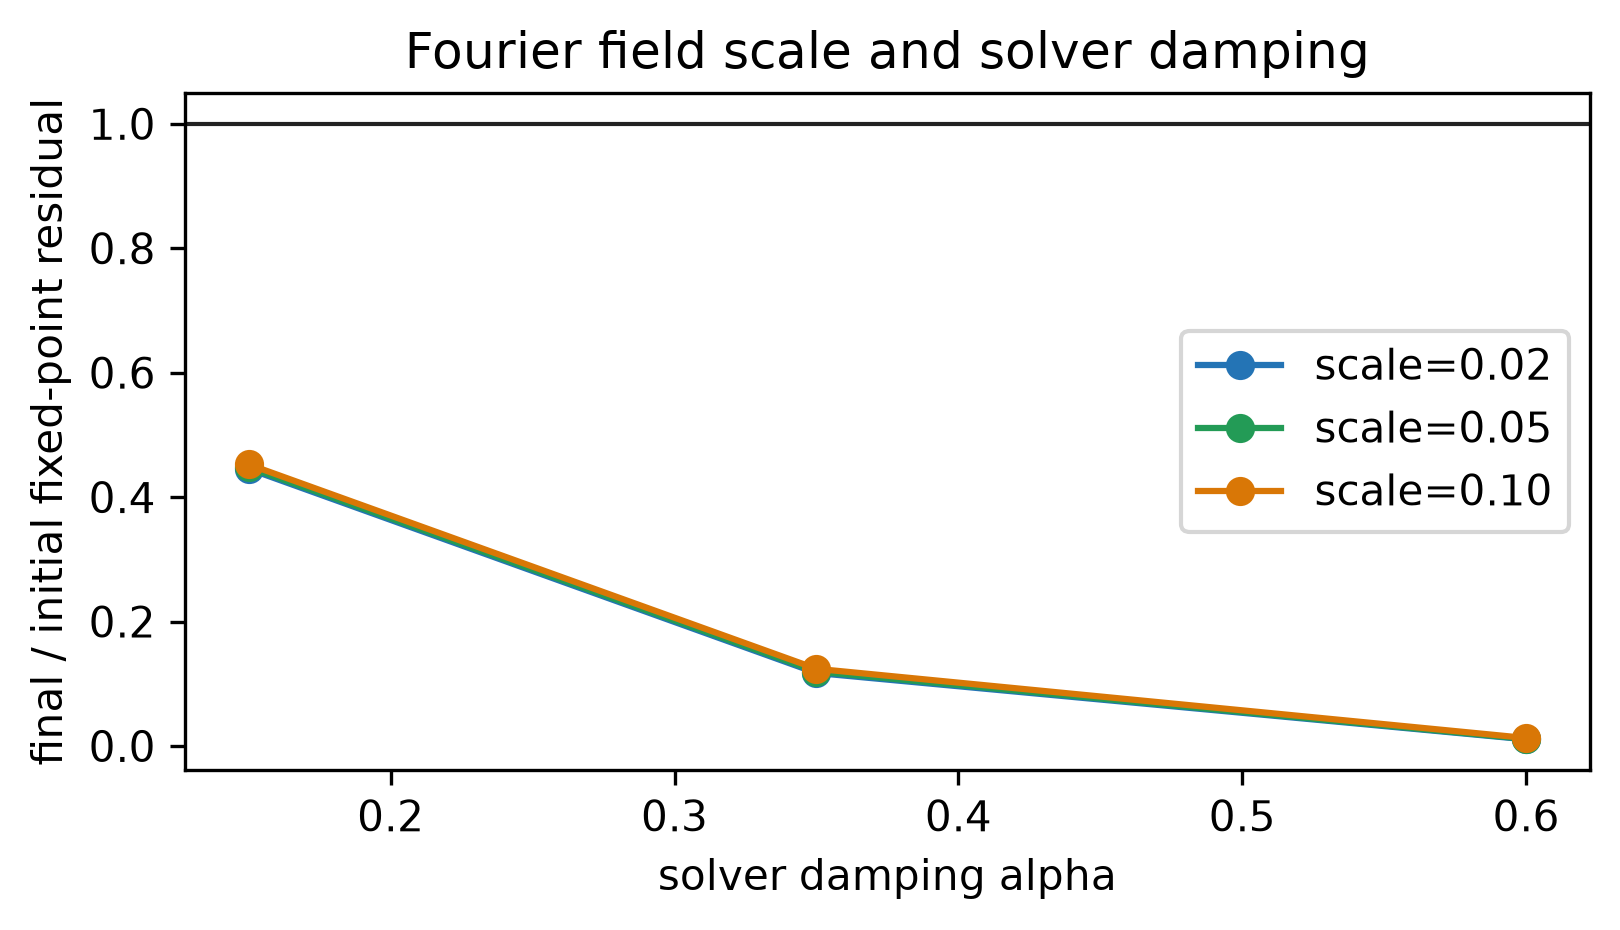

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
colors = ("#2474b5", "#239b56", "#d97706")
for color, scale in zip(colors, scales):
    ax.plot(alphas, sweep[scale], marker="o", color=color, label=f"scale={scale:.2f}")
ax.axhline(1.0, color="#222222", linewidth=1)
ax.set_xlabel("solver damping alpha")
ax.set_ylabel("final / initial fixed-point residual")
ax.set_title("Fourier field scale and solver damping")
ax.legend()
fig.tight_layout()

## 12. Public Numerical Operators

The earlier cells wrote the stencil explicitly so every index was visible. The
public functions implement the same discrete objects and keep them independent
from a learned model:

$$
r_{\mathrm{PDE}}=-\Delta_hu-q,
\qquad
\varepsilon_{\mathrm{PDE}}
=\frac{\lVert r_{\mathrm{PDE}}\rVert_2}{\lVert q\rVert_2+\epsilon}.
$$

In [19]:
spacing = 1.0 / (solution.shape[-1] - 1)
public_residual = poisson_residual_2d(
    solution,
    physical_source,
    spacing=spacing,
)
public_relative_residual = relative_residual_norm(
    public_residual,
    physical_source[..., 1:-1, 1:-1],
)

stencil_discrepancy = (public_residual - target_pde_residual).abs().max()
print("public Poisson residual:", f"{float(public_relative_residual):.3e}")
print("maximum stencil implementation discrepancy:", f"{float(stencil_discrepancy):.3e}")
print("zero-boundary error:", f"{float(boundary_error_2d(solution)):.3e}")
assert float(stencil_discrepancy) < 2.0e-4

public Poisson residual: 2.221e-02
maximum stencil implementation discrepancy: 1.068e-04
zero-boundary error: 4.497e-08


## 13. Reaction-Diffusion as an Implicit SILVA Step

For

$$
\frac{\partial u}{\partial t}
=D\Delta u+\rho u(1-u)+s,
$$

backward Euler solves

$$
u^{n+1}
=u^n+\Delta t\left[
D\Delta_hu^{n+1}
+\rho u^{n+1}(1-u^{n+1})+s^{n+1}
\right].
$$

`SILVAReactionDiffusionRHS2D` defines the bracketed field.
`SILVAImplicitTimeStep` adds the previous state, scales by $\Delta t$, applies
the boundary projector, and calls the package equilibrium solver.

In [20]:
class LogisticReaction(nn.Module):
    def __init__(self, rate=0.2):
        super().__init__()
        self.rate = float(rate)

    def forward(self, state):
        return self.rate * state * (1.0 - state)


rd_size = 12
rd_axis = torch.linspace(0.0, 1.0, rd_size)
rd_y, rd_x = torch.meshgrid(rd_axis, rd_axis, indexing="ij")
rd_previous = enforce_dirichlet_boundary_2d(
    (0.25 * torch.sin(math.pi * rd_x) * torch.sin(math.pi * rd_y))[None, None]
)
rd_forcing = torch.zeros_like(rd_previous)

rd_rhs = SILVAReactionDiffusionRHS2D(
    diffusion=0.01,
    reaction=LogisticReaction(0.2),
    spacing=1.0 / (rd_size - 1),
    boundary="dirichlet",
)
rd_step = SILVAImplicitTimeStep(
    rd_rhs,
    step_size=0.005,
    projector=SILVADirichletBoundary2D(0.0),
    config=SolverConfig(solver="picard", max_iter=40, tol=1e-7, alpha=0.8),
)
rd_result = rd_step(rd_previous, context=rd_forcing, return_result=True)

print("reaction-diffusion state:", tuple(rd_result.z.shape))
print("iterations:", rd_result.iterations)
print("fixed-point residual:", f"{rd_result.residual:.3e}")
print("boundary error:", f"{float(boundary_error_2d(rd_result.z)):.3e}")
assert float(boundary_error_2d(rd_result.z)) < 1.0e-8

reaction-diffusion state: (1, 1, 12, 12)
iterations: 7
fixed-point residual: 7.696e-08
boundary error: 0.000e+00


## 14. Viscous Burgers Equation

For the periodic one-dimensional equation

$$
\frac{\partial u}{\partial t}
+u\frac{\partial u}{\partial x}
=\nu\frac{\partial^2u}{\partial x^2}+s,
$$

the package uses centered differences

$$
(D_hu)_i=\frac{u_{i+1}-u_{i-1}}{2h},
\qquad
(\Delta_hu)_i=\frac{u_{i-1}-2u_i+u_{i+1}}{h^2},
$$

and the implicit field $-uD_hu+\nu\Delta_hu+s$. This transparent stencil is
useful for derivation and validation. More demanding flow regimes generally
need a problem-specific flux and stabilization module.

In [21]:
burgers_points = 48
burgers_axis = torch.arange(burgers_points) / burgers_points
burgers_previous = (0.35 * torch.sin(2.0 * math.pi * burgers_axis))[None, None]
burgers_rhs = SILVABurgersRHS1D(
    viscosity=0.01,
    spacing=1.0 / burgers_points,
    boundary="periodic",
)
burgers_step = SILVAImplicitTimeStep(
    burgers_rhs,
    step_size=0.001,
    config=SolverConfig(solver="picard", max_iter=30, tol=1e-7, alpha=0.8),
)
burgers_result = burgers_step(burgers_previous, return_result=True)

print("Burgers state:", tuple(burgers_result.z.shape))
print("iterations:", burgers_result.iterations)
print("fixed-point residual:", f"{burgers_result.residual:.3e}")
assert torch.isfinite(burgers_result.z).all()

Burgers state: (1, 1, 48)
iterations: 8
fixed-point residual: 9.947e-08


## 15. Coefficient-to-Solution Learning

Consider the variable-coefficient elliptic equation

$$
-\nabla\cdot(a(x,y)\nabla u(x,y))=q(x,y),
\qquad u|_{\partial\Omega}=0.
$$

The operator input has two channels, $(a,q)$, and the output is $u$. We use a
manufactured discrete dataset: choose $a$ and $u$, apply a conservative
face-flux discretization, and define $q$ from that discrete equation. The
resulting triplet satisfies the chosen grid equation by construction.

In [22]:
def variable_coefficient_source(coefficient, field, spacing):
    a_x = 0.5 * (coefficient[..., :, 1:] + coefficient[..., :, :-1])
    a_y = 0.5 * (coefficient[..., 1:, :] + coefficient[..., :-1, :])
    flux_x = a_x * (field[..., :, 1:] - field[..., :, :-1]) / spacing
    flux_y = a_y * (field[..., 1:, :] - field[..., :-1, :]) / spacing
    source_field = torch.zeros_like(field)
    source_field[..., 1:-1, 1:-1] = -(
        (flux_x[..., 1:-1, 1:] - flux_x[..., 1:-1, :-1]) / spacing
        + (flux_y[..., 1:, 1:-1] - flux_y[..., :-1, 1:-1]) / spacing
    )
    return source_field


def make_coefficient_operator_batch(samples=12, size=12, seed=157):
    generator = torch.Generator().manual_seed(seed)
    axis = torch.linspace(0.0, 1.0, size)
    y, x = torch.meshgrid(axis, axis, indexing="ij")
    amplitude = 0.2 + 0.6 * torch.rand(samples, 1, 1, 1, generator=generator)
    variation = -0.35 + 0.7 * torch.rand(samples, 1, 1, 1, generator=generator)
    coefficient = 1.0 + variation * torch.sin(2.0 * math.pi * x) * torch.sin(2.0 * math.pi * y)
    solution_field = amplitude * torch.sin(math.pi * x) * torch.sin(math.pi * y)
    spacing = 1.0 / (size - 1)
    source_field = variable_coefficient_source(coefficient, solution_field, spacing)
    source_scale = 40.0
    problem = torch.cat([coefficient, source_field / source_scale], dim=1)
    return problem, solution_field, source_field


coefficient_problem, coefficient_solution, coefficient_source = make_coefficient_operator_batch()
print("problem channels:", tuple(coefficient_problem.shape))
print("solution field:", tuple(coefficient_solution.shape))
print("physical source:", tuple(coefficient_source.shape))

problem channels: (12, 2, 12, 12)
solution field: (12, 1, 12, 12)
physical source: (12, 1, 12, 12)


In [23]:
torch.manual_seed(158)
coefficient_model = SILVAFourierNeuralOperator(
    in_channels=2,
    state_channels=4,
    out_channels=1,
    modes_height=4,
    modes_width=4,
    field_scale=0.05,
    output_transform=SILVADirichletBoundary2D(0.0),
    config=SolverConfig(solver="picard", max_iter=8, tol=1e-5, alpha=0.5),
)
coefficient_optimizer = torch.optim.Adam(coefficient_model.parameters(), lr=1.0e-2)
coefficient_losses = []

for step_index in range(30):
    coefficient_optimizer.zero_grad()
    coefficient_prediction = coefficient_model(coefficient_problem)
    coefficient_loss = F.mse_loss(coefficient_prediction, coefficient_solution)
    coefficient_loss.backward()
    coefficient_optimizer.step()
    coefficient_losses.append(float(coefficient_loss.detach()))

print("initial coefficient-to-solution loss:", f"{coefficient_losses[0]:.4e}")
print("final coefficient-to-solution loss:", f"{coefficient_losses[-1]:.4e}")
assert coefficient_losses[-1] < coefficient_losses[0]

initial coefficient-to-solution loss: 1.8187e-02
final coefficient-to-solution loss: 8.2755e-03


In [24]:
fine_problem, fine_solution, _ = make_coefficient_operator_batch(samples=2, size=18, seed=159)
with torch.no_grad():
    coarse_output = coefficient_model(coefficient_problem[:2])
    fine_output = coefficient_model(fine_problem)

print("coarse output:", tuple(coarse_output.shape))
print("fine output:", tuple(fine_output.shape))
print("fine boundary error:", f"{float(boundary_error_2d(fine_output)):.3e}")
assert fine_output.shape == fine_solution.shape

coarse output: (2, 1, 12, 12)
fine output: (2, 1, 18, 18)
fine boundary error: 0.000e+00


The fine-grid call verifies that the same spectral parameters can be evaluated
on another resolution. It does not establish resolution generalization. That
requires a held-out fine-grid error and the variable-coefficient physical
residual at the fine spacing.

## 16. Irregular Domains as Graph PDEs

For graph nodes and edges,

$$
(\Delta_Gz)_i=\sum_{j:(j,i)\in E}(z_j-z_i).
$$

An implicit graph-diffusion step puts $z^n$ in the stimulus and
$\Delta tD\Delta_Gz^{n+1}$ in `local_terms`. Edge geometry or material data can
enter the same local module through `edge_attr`.

In [25]:
class GraphDiffusionField(nn.Module):
    def __init__(self, scale):
        super().__init__()
        self.scale = float(scale)

    def forward(self, state, edge_index):
        source_nodes, target_nodes = edge_index
        field = torch.zeros_like(state)
        field.index_add_(0, target_nodes, state[source_nodes] - state[target_nodes])
        return self.scale * field


graph_nodes = 10
forward_nodes = torch.arange(graph_nodes)
next_nodes = torch.roll(forward_nodes, shifts=-1)
graph_edges = torch.stack(
    [
        torch.cat([forward_nodes, next_nodes]),
        torch.cat([next_nodes, forward_nodes]),
    ]
)
graph_previous = torch.sin(2.0 * math.pi * forward_nodes / graph_nodes)[:, None]

graph_step = SILVACortexLayer(
    input_encoder=nn.Identity(),
    local_terms=GraphDiffusionField(scale=0.1),
    activation=lambda z: z,
    output_activation=lambda z: z,
    normalize=False,
    config=SolverConfig(solver="picard", max_iter=30, tol=1e-7, alpha=0.8),
)
graph_result = graph_step(graph_previous, edge_index=graph_edges, return_result=True)

print("graph state:", tuple(graph_result.z.shape))
print("graph fixed-point residual:", f"{graph_result.residual:.3e}")
assert graph_result.z.shape == graph_previous.shape

graph state: (10, 1)
graph fixed-point residual: 6.144e-08


## 17. What to Use Where

| Goal | SILVA construction |
| --- | --- |
| finite ODE trajectory | `SILVAEulerFlowBlock` with a state-shaped vector field |
| ODE steady state | `SILVACortexLayer` whose transition has the desired stationary point |
| local PDE correction | convolution, graph, stencil, or flux module in `local_terms` |
| global PDE correction | Fourier operator or attention in `state_network` or `global_terms` |
| source-to-solution operator | lifting `input_encoder`, operator transition, equilibrium solver, physical readout |
| irregular mesh | graph local field plus geometry or edge attributes |
| nonperiodic boundary | mask, boundary channels, constrained output module, or geometry-specific basis |
| reaction-diffusion | `SILVAReactionDiffusionRHS2D` inside `SILVAImplicitTimeStep` |
| viscous Burgers | `SILVABurgersRHS1D` inside `SILVAImplicitTimeStep` |
| coefficient-to-solution learning | coefficient and source input channels in `SILVAOperatorModel` or `SILVAFourierNeuralOperator` |
| graph PDE | graph Laplacian, flux, or message module in `SILVACortexLayer.local_terms` |

The Fourier field is one possible internal architecture. U-Net supplies
multiscale local structure, graph operators support irregular domains,
Transformers support tokenized fields, and custom modules can encode a known
discretization. SILVA supplies the common structured transition, solver,
residuals, and gradient path around those choices.

Primary sources: [Neural Ordinary Differential Equations](https://arxiv.org/abs/1806.07366),
[Fourier Neural Operator for Parametric Partial Differential Equations](https://openreview.net/forum?id=c8P9NQVtmnO),
[Neural Operator: Learning Maps Between Function Spaces With Applications to PDEs](https://www.jmlr.org/papers/v24/21-1524.html),
and [SILVA Networks](https://arxiv.org/abs/2607.28989).

## From 15 Neural Operators Ode Pde to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the evolving or terminal physical state |
| Condition | time, initial condition, and external forcing |
| Repeated computation | an explicit flow step or residual field T(z, x) - z |
| Required invariants | time-step shape, initial condition, and integration consistency |
| Replaceable components | vector field, integrator, equilibrium transition, readout, and tolerances |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Scientific Operator

```python
operator = SILVAOperatorModel(
    in_channels=input_fields,
    state_channels=width,
    out_channels=solution_fields,
    input_encoder=my_lift,
    architecture=my_shape_preserving_operator,
    local_terms=[my_discretized_pde],
    global_terms=[my_integral_operator],
    readout=my_projection,
    config=solver_config,
)
```

The internal architecture may be spectral, convolutional, graph based, kernel
integral, wavelet based, or a composition, provided it preserves the sampled
state field.


In [26]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**trajectory error, terminal fixed-point residual, and conservation error**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **time horizon, step count, state dimension, and stiffness**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [27]:
notebook_reproduction_record = {
    "notebook": '15_neural_operators_ode_pde.ipynb',
    "state": 'the evolving or terminal physical state',
    "condition": 'time, initial condition, and external forcing',
    "transition": 'an explicit flow step or residual field T(z, x) - z',
    "invariants": 'time-step shape, initial condition, and integration consistency',
    "compact_metric": 'trajectory error, terminal fixed-point residual, and conservation error',
    "scale_axis": 'time horizon, step count, state dimension, and stiffness',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '15_neural_operators_ode_pde.ipynb',
 'state': 'the evolving or terminal physical state',
 'condition': 'time, initial condition, and external forcing',
 'transition': 'an explicit flow step or residual field T(z, x) - z',
 'invariants': 'time-step shape, initial condition, and integration consistency',
 'compact_metric': 'trajectory error, terminal fixed-point residual, and conservation error',
 'scale_axis': 'time horizon, step count, state dimension, and stiffness'}

## Where to Go Next

| Question | Page |
| --- | --- |
| How do operators, ODEs, and PDEs connect to SILVA? | [Neural Operators, ODEs, PDEs, and SILVA](https://jseluis.github.io/silva-networks/learn/neural-operators-ode-pde/) |
| Where do the compact ODE, PDE, Fourier, and graph cases run? | [Scientific Operators Example](https://jseluis.github.io/silva-networks/examples/scientific-operators/) |
| Which numerical and learned scientific objects are public? | [Scientific Operators API](https://jseluis.github.io/silva-networks/api/scientific/) |
